# **Assignment 5 - Apply 'SMOTE' Technique and Train Different Models on FER 2013 Dataset**

**Name -** Devanshee Gupta \
**Scholar No.-** 25P02F1001


## **1. Download 'FER 2013' Dataset from kaggle**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


## **2. Load dataset**

In [ ]:
import os

# List the contents of the dataset directory
dataset_path = path
print(f"Contents of {dataset_path}:")
for item in os.listdir(dataset_path):
    print(item)

Contents of /kaggle/input/fer2013:
test
train


In [ ]:
import cv2
import numpy as np
import os

# Define the base path to the dataset
dataset_base_path = path

# Construct full paths to the 'train' and 'test' directories
train_dir = os.path.join(dataset_base_path, 'train')
test_dir = os.path.join(dataset_base_path, 'test')

# Initialize empty lists to store image data and labels
images = []
labels = []

# Define image size (common for FER2013)
IMG_SIZE = 48

# Emotion labels mapping (assuming directory names are the labels)
# We'll build this dynamically by sorting the directory names
emotion_labels = sorted(os.listdir(train_dir))
emotion_map = {label: i for i, label in enumerate(emotion_labels)}

print(f"Emotion labels found: {emotion_labels}")

# Loop through both 'train' and 'test' directories
for data_dir in [train_dir, test_dir]:
    print(f"Processing directory: {data_dir}")
    for emotion_name in os.listdir(data_dir):
        emotion_path = os.path.join(data_dir, emotion_name)
        if os.path.isdir(emotion_path):
            label = emotion_map[emotion_name]
            for img_name in os.listdir(emotion_path):
                img_path = os.path.join(emotion_path, img_name)
                try:
                    img = cv2.imread(img_path)
                    # Convert to grayscale
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    # Resize to 48x48
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    images.append(img)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")

# Convert lists to NumPy arrays0
images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Shape of images array: {images.shape}")
print(f"Shape of labels array: {labels.shape}")
print(f"First 5 labels: {labels[:5]}")


Emotion labels found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Processing directory: /kaggle/input/fer2013/train
Processing directory: /kaggle/input/fer2013/test
Total images loaded: 35887
Shape of images array: (35887, 48, 48)
Shape of labels array: (35887,)
First 5 labels: [6 6 6 6 6]


## **3.  Verify and Adjust Split Ratio**

Split the loaded image data and labels into training and testing sets with a 70:30 ratio.


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.3, stratify=labels, random_state=42)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (25120, 48, 48)
Shape of X_test: (10767, 48, 48)
Shape of y_train: (25120,)
Shape of y_test: (10767,)


## **4. Preprocess Data**


Preprocess the image data, which includes normalizing pixel values and flattening the images for logistic regression.


In [ ]:
import numpy as np

# 1. Normalize pixel values to be between 0 and 1
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# 2. Reshape the images into 1D vectors (flattening)
X_train_flattened = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flattened = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print(f"Original X_train shape: {X_train.shape}")
print(f"Normalized X_train shape: {X_train_normalized.shape}")
print(f"Flattened X_train shape: {X_train_flattened.shape}")

print(f"Original X_test shape: {X_test.shape}")
print(f"Normalized X_test shape: {X_test_normalized.shape}")
print(f"Flattened X_test shape: {X_test_flattened.shape}")

Original X_train shape: (25120, 48, 48)
Normalized X_train shape: (25120, 48, 48)
Flattened X_train shape: (25120, 2304)
Original X_test shape: (10767, 48, 48)
Normalized X_test shape: (10767, 48, 48)
Flattened X_test shape: (10767, 2304)


### **Apply SMOTE technique**

In [ ]:
import sys
!{sys.executable} -m pip install imblearn


In [ ]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_flattened, y_train)

print(f"Shape of X_train_resampled: {X_train_resampled.shape}")
print(f"Shape of y_train_resampled: {y_train_resampled.shape}")

Shape of X_train_resampled: (44044, 2304)
Shape of y_train_resampled: (44044,)


## **5. a] Train Logistic Regression Model**

Train a logistic regression model using the preprocessed training data.


In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model
# Set max_iter to a sufficiently large number for convergence
# 'liblinear' solver works well for small datasets and handles L1/L2 penalties.
logistic_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Fit the model to the training data
logistic_model.fit(X_train_resampled, y_train_resampled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## **5. b] Train SVM Model**


Train SVM model using the preprocessed training data.


In [ ]:
from sklearn.svm import SVC

# Instantiate SVC model
svc_model = SVC(random_state=42)

# Fit the model to the training data
svc_model.fit(X_train_resampled, y_train_resampled)

print("SVM model trained successfully.")

SVM model trained successfully.


## **5. c] Train ANN Model**

Train ANN model using the preprocessed training data.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Get the number of features from the flattened training data
input_dim = X_train_resampled.shape[1]

# Get the number of output classes (emotions)
num_classes = len(emotion_labels)

# Create a Sequential model
ann_model = Sequential([
    # Input layer
    Dense(256, activation='relu', input_shape=(input_dim,)),
    # Hidden layer 1
    Dense(128, activation='relu'),
    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
print("ANN Model Summary:")
ann_model.summary()

# Train the ANN model using the resampled data
print("\nTraining ANN Model...")
ann_model.fit(
    X_train_resampled, y_train_resampled,
    epochs=20, # Number of epochs can be adjusted
    batch_size=32, # Batch size can be adjusted
    validation_data=(X_test_flattened, y_test) # Use test set for validation
)

ANN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,879 (2.38 MB)

 Trainable params: 623,879 (2.38 MB)

 Non-trainable params: 0 (0.00 B)


Training ANN Model...
Epoch 1/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.2139 - loss: 1.9232 - val_accuracy: 0.3190 - val_loss: 1.7247
Epoch 2/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3295 - loss: 1.7232 - val_accuracy: 0.3206 - val_loss: 1.7041
Epoch 3/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3705 - loss: 1.6265 - val_accuracy: 0.2959 - val_loss: 1.7587
Epoch 4/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.3908 - loss: 1.5692 - val_accuracy: 0.3379 - val_loss: 1.6729
Epoch 5/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4026 - loss: 1.5382 - val_accuracy: 0.3173 - val_loss: 1.7632
Epoch 6/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.4221 - loss: 1.4995 - val_accuracy: 0.3362 - val_loss: 1.6892
Epoch 7/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4318 - loss: 1.4628 - val_accuracy: 0.3463 - val_loss: 1.6486
Epoch 8/20
1377/1377 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/st

## **6. Evaluate Models**

Evaluate the trained model's performance on the testing data.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

1. Logistic Regression

In [ ]:
# Make predictions on the flattened test data
y_pred = logistic_model.predict(X_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=emotion_labels))

# Generate a confusion matrix
print("\nConfusion Matrix:")
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)

Accuracy: 0.3160

Classification Report:
              precision    recall  f1-score   support

       angry       0.22      0.22      0.22      1486
     disgust       0.07      0.32      0.11       164
        fear       0.23      0.20      0.21      1536
       happy       0.50      0.42      0.45      2697
     neutral       0.31      0.28      0.29      1860
         sad       0.27      0.24      0.25      1823
    surprise       0.38      0.53      0.44      1201

    accuracy                           0.32     10767
   macro avg       0.28      0.31      0.29     10767
weighted avg       0.33      0.32      0.32     10767


Confusion Matrix:
[[ 330  127  188  260  206  229  146]
 [  19   52   29   14   14   20   16]
 [ 195   96  312  206  225  241  261]
 [ 319  175  265 1123  290  296  229]
 [ 230  108  203  303  519  299  198]
 [ 274  136  263  257  295  432  166]
 [ 104   50  118   84  110  101  634]]


2. SVC

In [ ]:
# Make predictions on the flattened test data
y_pred_svc = svc_model.predict(X_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy: {accuracy:.4f}")

# Generate a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, target_names=emotion_labels))

# Generate a confusion matrix
print("\nConfusion Matrix:")
cm2 = confusion_matrix(y_test, y_pred_svc)
print(cm2)

Accuracy: 0.4413

Classification Report:
              precision    recall  f1-score   support

       angry       0.34      0.33      0.33      1486
     disgust       0.55      0.43      0.49       164
        fear       0.34      0.28      0.31      1536
       happy       0.55      0.59      0.57      2697
     neutral       0.42      0.40      0.41      1860
         sad       0.34      0.38      0.36      1823
    surprise       0.58      0.62      0.60      1201

    accuracy                           0.44     10767
   macro avg       0.45      0.43      0.44     10767
weighted avg       0.44      0.44      0.44     10767


Confusion Matrix:
[[ 486    9  156  311  192  265   67]
 [  17   71   19   11   14   25    7]
 [ 190    9  430  219  212  305  171]
 [ 235   10  161 1587  251  337  116]
 [ 181    8  156  351  738  326  100]
 [ 244   20  236  273  282  697   71]
 [  67    1  112  116   87   75  743]]


3. ANN

In [ ]:
import numpy as np

# Make predictions on the flattened test data
y_pred_ann_probabilities = ann_model.predict(X_test_flattened)

# Convert probabilities to class labels
y_pred_ann = np.argmax(y_pred_ann_probabilities, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_ann)
print(f"Accuracy: {accuracy:.4f}")

# Generate a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=emotion_labels))

# Generate a confusion matrix
print("\nConfusion Matrix:")
cm3 = confusion_matrix(y_test, y_pred_ann)
print(cm3)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.3376

Classification Report:
              precision    recall  f1-score   support

       angry       0.23      0.36      0.28      1486
     disgust       0.11      0.42      0.17       164
        fear       0.20      0.24      0.22      1536
       happy       0.50      0.55      0.52      2697
     neutral       0.39      0.18      0.25      1860
         sad       0.32      0.15      0.20      1823
    surprise       0.45      0.48      0.47      1201

    accuracy                           0.34     10767
   macro avg       0.31      0.34      0.30     10767
weighted avg       0.36      0.34      0.33     10767


Confusion Matrix:
[[ 535   83  248  316  107   99   98]
 [  29   69   25   20    2   10    9]
 [ 384  107  371  273   83  110  208]
 [ 415  117  297 1471  112  150  135]
 [ 395   91  314  382  335  176  167]
 [ 472  115  380  314  167  272  103]
 [ 141   46  205  152   50   25  582]]


### **7. Visualizing the Confusion Matrix**

To better understand the model's performance across different emotion classes, let's visualize the confusion matrix.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

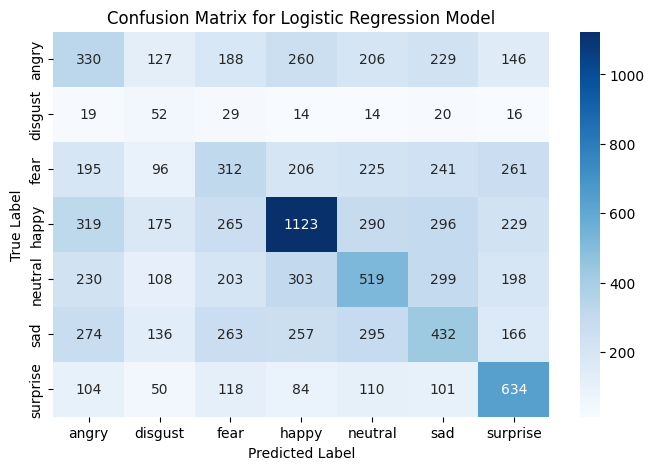

In [ ]:
# Plotting the confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

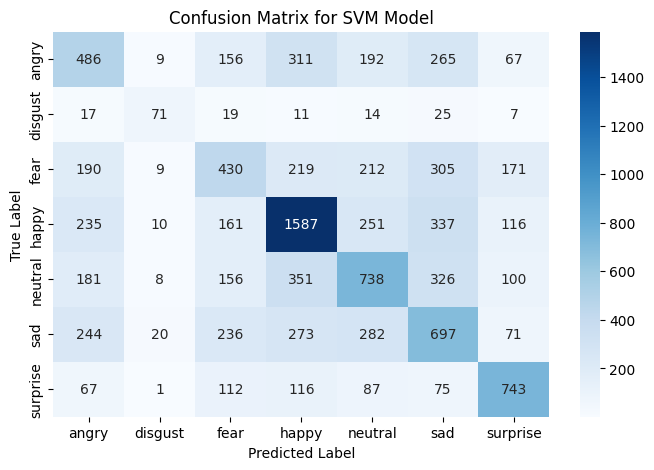

In [ ]:
# Plotting the confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model')
plt.show()

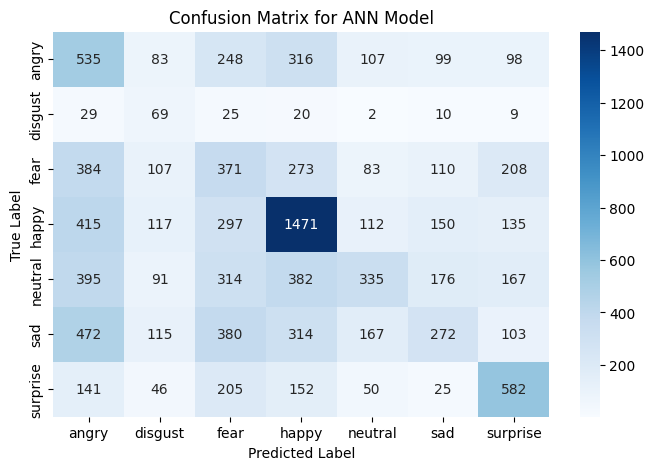

In [ ]:
# Plotting the confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ANN Model')
plt.show()

## **8. Assignment Summary**


*   **Data Loading and Preprocessing**:
    *   The dataset contains 7 emotion labels: 'angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'.
    *   All images were converted to grayscale and resized to a standard 48x48 pixel dimension.
    *   The entire dataset was successfully loaded and prepared as NumPy arrays.
    *   SMOTE Technique was applied as well.
*   **Data Splitting**:
    *   The loaded data was split into training and testing sets with a 70:30 ratio, using stratification to maintain class distribution.
    *   The training set (`X_train`, `y_train`) consists of 25,120 samples, each image being 48x48 pixels.
    *   The testing set (`X_test`, `y_test`) consists of 10,767 samples, each image being 48x48 pixels.
*   **Data Normalization and Flattening**:
    *   Image pixel values were normalized to a range between 0 and 1 by dividing by 255.0.
    *   Normalized images were flattened from their 48x48 pixel format into 1D vectors of 2,304 features.
    *   The preprocessed training data (`X_train_flattened`) has a shape of (25120, 2304), and the testing data (`X_test_flattened`) has a shape of (10767, 2304).
    *  After applying SMOTE, training data (`X_train_resampled`) has a shape of (44044, 2304).
*   **Model Training**:
    *   A Logistic Regression, SVM, ANN model were successfully trained on the preprocessed training data (`X_train_resampled`, `y_train_resampled`).
*   **Model Accuracy**:
    *   Logistic Regression - 0.3160
    *   SVM Model - 0.4413
    *   ANN Model - 0.3376
    
**After observing all other metrics as well, the conclusion is that SVM worked best among all on FER 2013 dataset.**

---